In [6]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score
import os
import random
import re
import pandas as pd
from pybnesian import LinearCorrelation, MutualInformation, KMutualInformation, RCoT
import re
import ot 
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import pingouin as pg
from extra import hsic, XtendedCorrel
import openpyxl

In [7]:
seedR = random.Random(42)
seedN = np.random.default_rng()

In [8]:
#AUX:

#Only contains the two variables
#each pair is of size (N,2)
def getnumpy(df):
    data=df.to_numpy()
    tables=[]
    for i in range(data.shape[0]):
        tables.append(np.array([data[i][0], data[i][1]]))
        
    return tables

def getTuebingen():
    pairmeta_file = "../Pairs/pairmeta.txt"
    pair_prefix = "pair"
    data = []    # List to store tuples: (x_matrix, y_matrix)
    weights = [] # List to store weight values

    # Read metadata file
    with open(pairmeta_file, 'r') as meta_file:
        meta_lines = meta_file.readlines()
    
    for line in meta_lines:
        entries = line.split()
        # Read the pair number and format it with leading zeros (e.g., '0001')
        pair_number = entries[0].zfill(4)
        
        # Parse the starting and ending indices for x and y.
        # Subtract 1 from the starting index to convert from 1-indexed to 0-indexed.
        x_start = int(entries[1]) - 1
        x_end = int(entries[2])      # Slicing in Python is end-exclusive.
        y_start = int(entries[3]) - 1
        y_end = int(entries[4])
        
        # Parse the weight value (column 6)
        weight = float(entries[5])
        
        # Build the filename for the corresponding pair file.
        pair_filename = f"../Pairs/{pair_prefix}{pair_number}.txt"
        try:
            pair_data = np.loadtxt(pair_filename)
            
            # Extract the submatrices for x and y using slicing.
            # The columns for x and y can be more than one column.
            x_data = pair_data[:, x_start:x_end]
            y_data = pair_data[:, y_start:y_end]
            
            # Append the tuple (x_data, y_data) to the data list.
            data.append((x_data, y_data))
            weights.append(weight)
            
        except FileNotFoundError:
            print(f"Warning: {pair_filename} not found, skipping.")
    
    return data, np.array(weights)

# Example usage:
# data, weights = load_pairs_and_weights("pairmeta.txt")


def reorder_by_abs(scores, weights):
    valid_mask = ~np.isnan(scores)
    
    # Filter out NaN entries from both scores and weights
    valid_scores = scores[valid_mask]
    valid_weights = weights[valid_mask]
    # Get indices that would sort the array by descending absolute value
    sorted_indices = np.argsort(-np.abs(valid_scores))
    
    # Apply the sorted indices to both scores and weights
    sorted_scores = valid_scores[sorted_indices]
    sorted_weights = valid_weights[sorted_indices]

    return sorted_scores, sorted_weights

def minmax_scale(data):
    # Compute the minimum and maximum for each column
    min_val = np.nanmin(data, axis=0)
    max_val = np.nanmax(data, axis=0)
    scale = max_val - min_val
    
    # To avoid division by zero, replace any 0 in scale with 1 temporarily
    scale_safe = np.where(scale == 0, 1, scale)
    
    # Perform the min-max scaling
    scaled_data = (data - min_val) / scale_safe
    
    # For columns with constant values, set the entire column to 0
    scaled_data[:, scale == 0] = 0
    return scaled_data

def sign_to_binary(x):
    return np.where(x > 0, 1, np.where(x < 0, 0, 0.5))

def switch_signs(vector):
    # Generate a binary vector (mask) with 0's and 1's equally likely.
    mask = np.random.choice([0, 1], size=vector.shape)
    
    # Make a copy of the original vector to avoid modifying it directly.
    new_vector = vector.copy()
    
    # Switch sign where mask is 0
    new_vector[mask == 0] *= -1
    
    return new_vector, mask

def sanitize_filename(filename):
    # Replace non-allowed characters with underscores
    sanitized = re.sub(r'[^a-zA-Z0-9_.-]', '_', filename)
    # Collapse multiple underscores into one
    sanitized = re.sub(r'_+', '_', sanitized)
    # Remove leading/trailing underscores
    return sanitized.strip('_')

def save_imgs(fig,title,filename, dir):
    os.makedirs(dir, exist_ok=True)  # Create directory if it doesn't exist
    fig.suptitle(title, fontsize=11, y=0.98)  # Reduced space, slightly larger font
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Prevents title from getting cut off

    # Ensure a valid filename
    filename = f"{dir}/{sanitize_filename(filename)}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')

def save_table(df,title,filename, dir):
    df = df.round(3)
    fig_width = df.shape[1] * 1.2
    fig_height = df.shape[0] * 0.8
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('tight')
    ax.axis('off')
    plt.title(title)
    # Create the table
    table = ax.table(cellText=df.values, colLabels=df.columns, rowLabels=df.index, cellLoc='center', loc='center')
    filename = f"{dir}/{sanitize_filename(filename)}.png"
    # Save the table as an image
    plt.savefig(filename, dpi=300, bbox_inches='tight')

def wasserstein_distance(x,y):
    M = ot.dist(x, y, metric='euclidean')
    n_samples=len(x)
    a = np.ones(n_samples) / n_samples
    b = np.ones(n_samples) / n_samples
    wasserstein_distance_squared = ot.emd2(a, b, M)
    return np.sqrt(wasserstein_distance_squared)

def remove_outliers(x, y,per=0.9):
    x, y = np.array(x), np.array(y)

    # Compute IQR for x and y
    Q1_x, Q3_x = np.percentile(x, [100*(1-per)/2, 100*(per+(1-per)/2)])
    #IQR_x = Q3_x - Q1_x
    #lower_x, upper_x = Q1_x - mul * IQR_x, Q3_x + mul* IQR_x
    lower_x,upper_x=Q1_x,Q3_x

    Q1_y, Q3_y = np.percentile(y, [100*(1-per)/2, 100*(per+(1-per)/2)])
    #IQR_y = Q3_y - Q1_y
    #lower_y, upper_y = Q1_y - mul * IQR_y, Q3_y + mul * IQR_y
    lower_y,upper_y=Q1_y,Q3_y

    # Create a mask for valid (non-outlier) points
    mask = (x >= lower_x) & (x <= upper_x) & (y >= lower_y) & (y <= upper_y)
    return x[mask], y[mask]

def derivative_polyfit(time, samples, r, poly_degree=2):
    """
    Estimate the derivative by fitting a polynomial to the last r samples and 
    differentiating the fitted polynomial at the most recent time.

    Parameters:
        time (list or np.array): Timestamps corresponding to each sample in chronological order,
                                 with the most recent sample at the end.
        samples (list or np.array): Data points corresponding to the time points.
        r (int): The number of recent samples to use for the fit.
        poly_degree (int): Degree of the polynomial to fit (default is 2).

    Returns:
        float: The estimated derivative at the current time.

    Raises:
        ValueError: If the number of samples or time points is less than r, 
                    or if the lengths of time and samples do not match.
    """
    if len(samples) < r or len(time) < r:
        raise ValueError(f"At least {r} samples are required.")
    if len(time) != len(samples):
        raise ValueError("Time and samples vectors must have the same length.")
    
    # Use the last r samples.
    y = np.array(samples[-r:])
    t_recent = np.array(time[-r:])
    
    # Shift the time vector so that the most recent sample corresponds to t = 0.
    t_shifted = t_recent - t_recent[-1]
    
    # Fit a polynomial of the given degree to the (t_shifted, y) data.
    coeffs = np.polyfit(t_shifted, y, poly_degree)
    
    # Compute the derivative of the polynomial.
    poly_deriv = np.polyder(coeffs)
    
    # Evaluate the derivative at t = 0 (the most recent sample).
    deriv_at_zero = np.polyval(poly_deriv, 0)
    
    return deriv_at_zero

In [9]:
#Completely random
def random_fun(data):
    if seedN.random()<0.2:
        return np.nan
    return seedR.random()-0.5

In [10]:
def save_excel(funcname, dataset, metrics, metric_titles, **kwargs):
    """
    Executes func with the provided kwargs, computes metrics from the result,
    and appends or overwrites a row in an Excel file ("results.xlsx") where:
      - The first column is the method name (),
      - The second column is the dataset,
      - The third column is a string of all kwargs,
      - Subsequent columns are the computed metric values.
      
    Parameters:
        func (function): The function to run.
        dataset (any): Identifier for the dataset.
        metrics (list of functions): Functions that compute a metric from func's output.
        metric_titles (list of str): Column titles for the metric values.
        **kwargs: Additional keyword arguments to pass to func.
    """
    
    # Convert kwargs to a readable string format
    kwargs_str = ", ".join(f"{k}={v}" for k, v in kwargs.items())
    
    # Prepare the row: [Method, Dataset, Parameters, ...metrics]
    row = [funcname, dataset, kwargs_str] + metrics

    file_path = "../previous_results.xlsx"
    if os.path.exists(file_path):
        wb = openpyxl.load_workbook(file_path)
        ws = wb.active
    else:
        wb = openpyxl.Workbook()
        ws = wb.active
        # Write header row if file is new
        header = ["Method", "Dataset", "Parameters"] + metric_titles
        ws.append(header)
    
    # Check if a row with the same Method, Dataset, and Parameters exists
    for row_idx, existing_row in enumerate(ws.iter_rows(values_only=True), start=1):
        #print(existing_row[2], kwargs_str, "==", (existing_row[2] or "")  == kwargs_str)
        if (existing_row[0] == funcname and 
            existing_row[1] == dataset and 
            (existing_row[2] or "") == kwargs_str):
            # Overwrite the existing row
            for col_idx, value in enumerate(row, start=1):
                ws.cell(row=row_idx, column=col_idx, value=value)
            wb.save(file_path)
            return
    
    # Append the new row if no match is found
    ws.append(row)
    wb.save(file_path)



#Methods return one number which is the score: If the score is negative it is the opposite direction: Y->X
def test_tuebingen(func,*args, **kwargs):
    data, weights = getTuebingen() #labels are always one!
          
    scores =np.array([func(d,*args, **kwargs) for d in data])
    weights = weights[~np.isnan(scores)]  
    scores=scores[~np.isnan(scores)]  # Remove NaN scores
    #AUROC
    y_scores, y_true = switch_signs(scores)
    normalized_y=minmax_scale(y_scores)
    normalized_y[np.isnan(normalized_y)] = 0.5
    auroc = roc_auc_score(y_true,normalized_y,sample_weight=weights)
    #Accuracy
    guess=sign_to_binary(scores)
    accuracy = sum(guess*weights)/sum(weights)

    save_excel(func.__name__,"tuebingen",[auroc,accuracy],["Auroc","Accuracy"])
    return auroc, accuracy


In [11]:
test_tuebingen(random_fun)

(np.float64(0.5643368947865164), np.float64(0.5670943970707412))

In [ ]:
#EVALUATION AUX
def call_f_N_times(dataset, method, N):
    # Initialize outputs as None until we know how many outputs there are
    outputs = None

    # Run the dataset(method) function N times
    for _ in range(N):
        result = dataset(method)
        # Ensure the result is a tuple (if not, make it one)
        if not isinstance(result, tuple):
            result = (result,)
        # Create lists for each output on the first call
        if outputs is None:
            num_vars = len(result)
            outputs = [[] for _ in range(num_vars)]
        # Append each returned value to the corresponding list
        for i, value in enumerate(result):
            outputs[i].append(value)
    
    # Determine subplot grid dimensions
    num_vars = len(outputs)
    num_cols = min(num_vars, 3)  # Use at most 3 columns per row
    num_rows = (num_vars + num_cols - 1) // num_cols  # Calculate required rows

    # Create the subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    
    # Flatten axes array for easier indexing if needed
    if num_vars == 1:
        axes = [axes]
    elif num_rows == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()
    
    titles=["AUROC","Accuracy"]
    # Plot a histogram for each output variable
    for i in range(num_vars):
        ax = axes[i]
        ax.hist(outputs[i], bins=15, color=f'C{i}', alpha=0.8, edgecolor='black', density=True)
        ax.set_title(titles[i], fontsize=14)
        ax.set_xlabel('Value', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.set_xlim(0,1)
        ax.grid(True, linestyle='--', alpha=0.6)
    
    # Remove any extra subplots if the grid has unused axes
    for j in range(num_vars, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    title=f"Histogram of Different Metrics: {method.__name__}"
    save_imgs(fig,title, title, "interesting")
    plt.show()

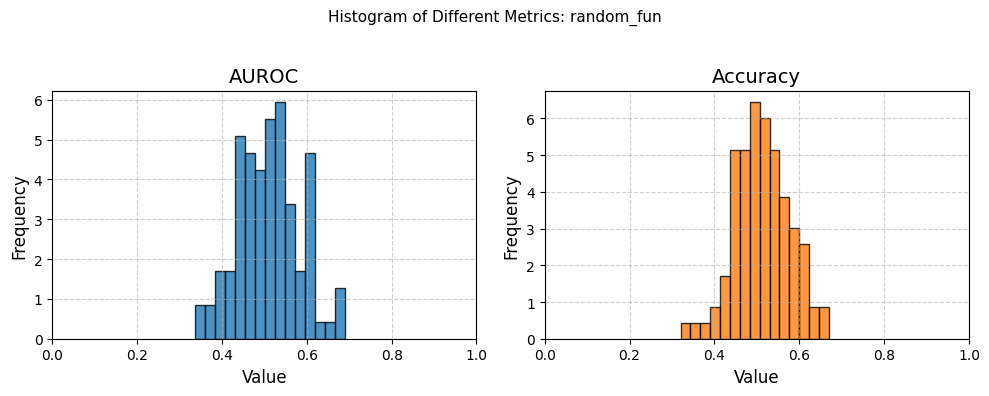

In [13]:
call_f_N_times(test_tuebingen, random_fun, 100)

In [ ]:
def test_independence(x,y,method="pearson", **kwargs):
    x=x.flatten()
    y=y.flatten()
    df = pd.DataFrame({"x": x, "y": y})

    if method=="pearson":
        pearson_corr, pearson_p = pearsonr(x, y)
        return - pearson_p
    elif method=="spearman":
        spearman_corr, spearman_p = spearmanr(x, y)
        return - spearman_p
    elif method=="hsic":
        return hsic.dHSIC(x, y) / np.sqrt(hsic.dHSIC(x, x) * hsic.dHSIC(y, y))
    elif method=="hoef":
        return XtendedCorrel.hoeffding(x,y)
    """
            The independence score. Note:
                - For "linear" and "rcot": a higher p-value means more evidence of independence.
                - For "mutual_info" and "kmutual": a score of 0 means independence, and higher values indicate dependence.
    """
    # Create a DataFrame with column names 'x' and 'y'
    
    
    if method == "linear":
        # For continuous data, use the partial linear correlation test.
        test = LinearCorrelation(df)
        # pvalue: higher p-value => cannot reject independence
        score = test.pvalue("x", "y")
        return - score

    elif method == "mutual_info":
        # Using MutualInformation (assumes a Gaussian model for continuous data)
        test = MutualInformation(df, asymptotic_df=True)
        # MI: 0 indicates independence; higher MI means more dependence.
        score = test.mi("x", "y")
        return score

    elif method == "kmutual":
        # Using KMutualInformation, a k-nearest neighbors estimator.
        k = kwargs.get("k", 5)
        seed = kwargs.get("seed", None)
        shuffle_neighbors = kwargs.get("shuffle_neighbors", 5)
        samples = kwargs.get("samples", 1000)
        test = KMutualInformation(df, k, seed=seed, shuffle_neighbors=shuffle_neighbors, samples=samples)
        score = test.mi("x", "y")
        return score

    elif method == "rcot":
        # Using RCoT, a randomized conditional correlation test based on random Fourier features.
        random_fourier_xy = kwargs.get("random_fourier_xy",15)
        random_fourier_z = kwargs.get("random_fourier_z", 100)
        test = RCoT(df, random_fourier_xy=random_fourier_xy, random_fourier_z=random_fourier_z)
        # pvalue: higher p-value indicates more independence.
        score = test.pvalue("x", "y")
        return - score
    elif method=="wasser": #mede o quao longe eq ta de ser ao calhas
        y_perm=np.random.permutation(y)
        dist_true=np.array([x,y])
        dist_perm=np.array([x,y_perm])
        return - wasserstein_distance(dist_true,dist_perm)    
